In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

path = '../data/subject-83'

df = pd.read_csv(path + ".tsv", sep='\t')
df.replace(['NA', 'undefined'], np.nan, inplace=True)
df['TIME'] = pd.to_numeric(df['TIME'], errors='coerce')
df['dx']   = pd.to_numeric(df['FPOGX'], errors='coerce')
df['dy']   = pd.to_numeric(df['FPOGY'], errors='coerce')
df['FPOGV'] = pd.to_numeric(df['FPOGV'], errors='coerce')
df = df.dropna(subset=['dx', 'dy']).sort_values('TIME').reset_index(drop=True)

csv = pd.read_csv(path + ".csv")

onsets     = df[df['USER'].notna() & df['USER'].str.contains('IMAGE_ONSET', na=False)]
img_markers = df[df['USER'].notna() & df['USER'].str.contains('IMG_LEFT', na=False)][['TIME', 'USER']]

segments = []
for i, (_, row) in enumerate(onsets.iterrows()):
    t0  = row['TIME']
    seg = df[(df['TIME'] >= t0) & (df['TIME'] < t0 + 5.0) & (df['FPOGV'] == 1) &
             (df['dx'] >= 0) & (df['dx'] <= 1) & (df['dy'] >= 0) & (df['dy'] <= 1)].copy()
    seg['t_rel'] = seg['TIME'] - t0
    img_row = img_markers[img_markers['TIME'] <= t0].tail(1)
    label   = img_row['USER'].values[0].strip() if len(img_row) else ''
    img_left  = label.split('IMG_LEFT=')[1].split(' ')[0]  if 'IMG_LEFT='  in label else '?'
    img_right = label.split('IMG_RIGHT=')[1].split(' ')[0] if 'IMG_RIGHT=' in label else '?'
    r = csv.iloc[i]

    lx = int(960 + r['x_left']);  ly = int(540 + r['y_left'])
    rx = int(960 + r['x_right']); ry = int(540 + r['y_right'])
    segments.append({'seg': seg, 'img_left': img_left, 'img_right': img_right,
                     'left_px': (lx, ly), 'right_px': (rx, ry),
                     'csv_side': r['first_fix_side'], 'csv_rt': r['first_fix_rt']})

print(f'{len(segments)} trials loaded')

8 trials loaded


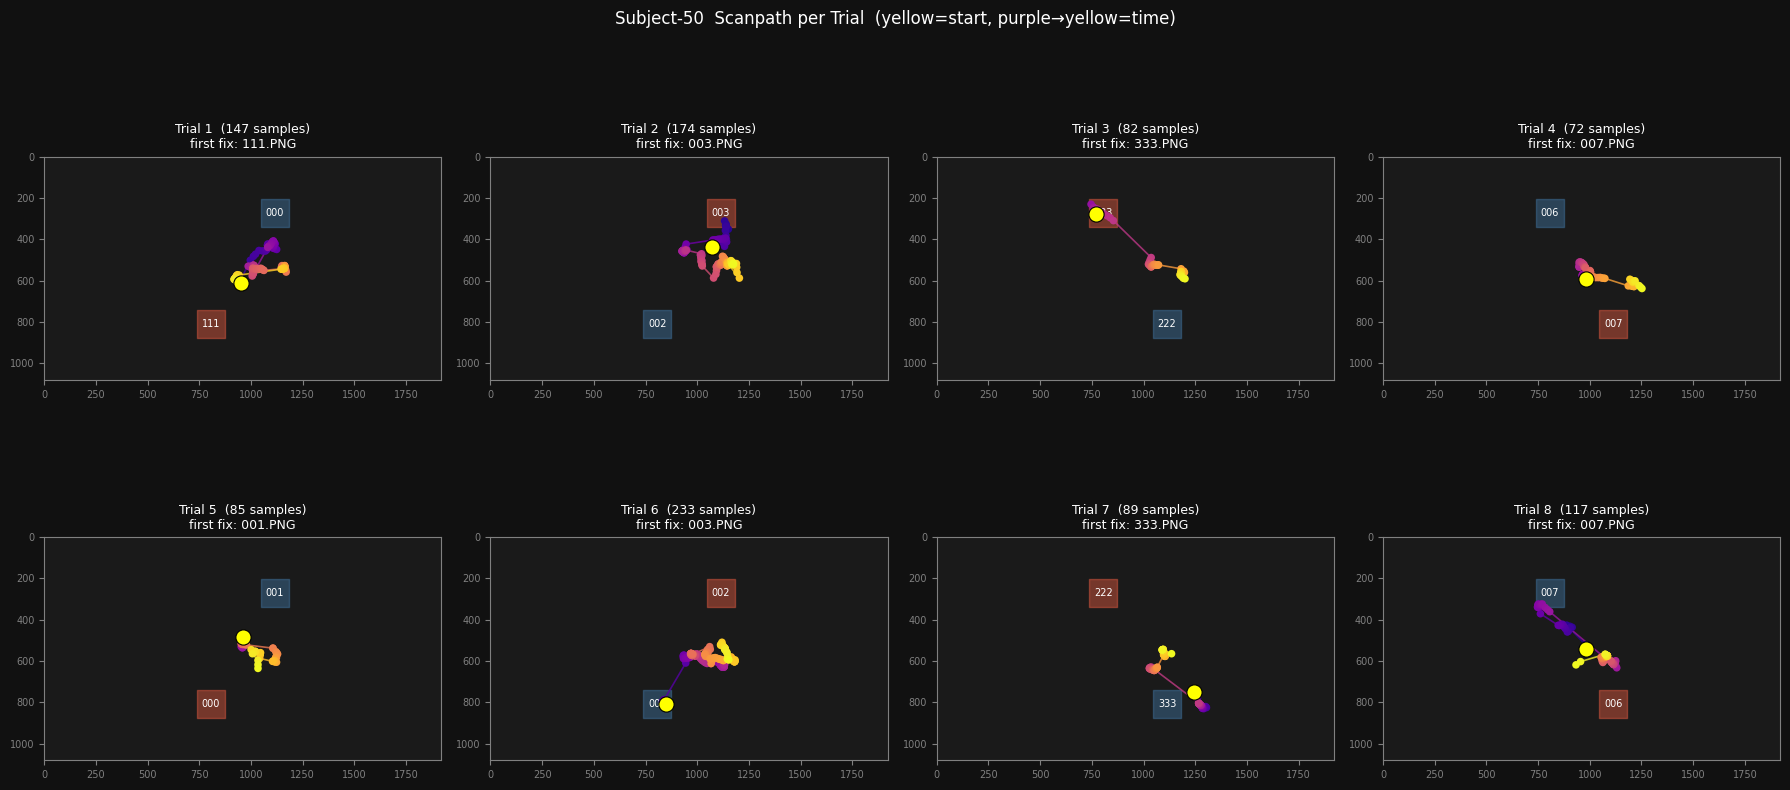

In [47]:
SCREEN_W, SCREEN_H = 1920, 1080

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for i, trial in enumerate(segments):
    ax  = axes[i // 4, i % 4]
    seg = trial['seg']
    lx, ly = trial['left_px']
    rx, ry = trial['right_px']

    ax.set_xlim(0, SCREEN_W)
    ax.set_ylim(SCREEN_H, 0)
    ax.set_facecolor('#1a1a1a')
    ax.set_aspect('equal')

    ax.scatter([lx], [ly], s=400, marker='s', color='steelblue', alpha=0.4, zorder=1, label=f'L:{trial["img_left"]}')
    ax.scatter([rx], [ry], s=400, marker='s', color='tomato',    alpha=0.4, zorder=1, label=f'R:{trial["img_right"]}')
    ax.text(lx, ly, trial['img_left'].replace('.PNG',''),  ha='center', va='center', fontsize=7, color='white')
    ax.text(rx, ry, trial['img_right'].replace('.PNG',''), ha='center', va='center', fontsize=7, color='white')

    if len(seg) >= 2:
        xs = seg['dx'].values * SCREEN_W
        ys = seg['dy'].values * SCREEN_H
        n  = len(xs)
        colors = cm.plasma(np.linspace(0, 1, n))

        for j in range(n - 1):
            ax.plot([xs[j], xs[j+1]], [ys[j], ys[j+1]], color=colors[j], lw=1.2, alpha=0.8)

        ax.scatter(xs, ys, c=np.linspace(0, 1, n), cmap='plasma',
                   s=30, zorder=5, edgecolors='none')

        ax.scatter([xs[0]], [ys[0]], s=120, color='yellow', zorder=6, edgecolors='black', linewidths=0.8)

    elif len(seg) == 1:
        xs = seg['dx'].values * SCREEN_W
        ys = seg['dy'].values * SCREEN_H
        ax.scatter(xs, ys, s=120, color='yellow', zorder=6, edgecolors='black', linewidths=0.8)

    first_img = 'unclear'
    if len(seg) >= 1:
        for xi, yi in zip(seg['dx'].values * SCREEN_W, seg['dy'].values * SCREEN_H):
            dl = np.hypot(xi - lx, yi - ly)
            dr = np.hypot(xi - rx, yi - ry)
            if abs(dl - dr) > 100:
                first_img = trial['img_left'] if dl < dr else trial['img_right']
                break

    ax.set_title(f'Trial {i+1}  ({len(seg)} samples)\nfirst fix: {first_img}',
                 fontsize=9, color='white')
    ax.tick_params(colors='gray', labelsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor('gray')

fig.patch.set_facecolor('#111111')
plt.suptitle('Subject-50  Scanpath per Trial  (yellow=start, purple→yellow=time)',
             fontsize=12, color='white')
plt.tight_layout()
plt.show()

In [48]:
# --- Trigger count and temporal distances ---
markers = df[df['USER'].notna()].copy()

# Count each marker type
print("Marker counts:")
print(markers['USER'].value_counts().to_string())

# Per-trial timing: STIMULUS_ONSET -> IMAGE_ONSET -> STOP_TRIAL
print("\nPer-trial timing (seconds from STIMULUS_ONSET):")
print(f"{'trial':<8} {'STIM->IMG':>10} {'IMG->STOP':>10}")
stim_times = markers[markers['USER'].str.contains('STIMULUS_ONSET', na=False)].copy()
img_times  = markers[markers['USER'].str.contains('IMAGE_ONSET',    na=False)].copy()
stop_times = markers[markers['USER'].str.contains('STOP_TRIAL',     na=False)].copy()

for idx, stim_row in enumerate(stim_times.itertuples()):
    img  = img_times[img_times['TIME'] >  stim_row.TIME].iloc[0]  if len(img_times[img_times['TIME']  > stim_row.TIME])  else None
    stop = stop_times[stop_times['TIME'] > stim_row.TIME].iloc[0] if len(stop_times[stop_times['TIME'] > stim_row.TIME]) else None
    stim_to_img  = f"{img['TIME']  - stim_row.TIME:.3f}" if img  is not None else "missing"
    img_to_stop  = f"{stop['TIME'] - img['TIME']:.3f}"   if (img is not None and stop is not None) else "missing"
    print(f"trial {idx+1:<3} {stim_to_img:>10} {img_to_stop:>10}")

Marker counts:
USER
IMAGE_ONSET                                                                               8
STOP_TRIAL                                                                                6
START_TRIAL                                                                               2
0                                                                                         1
MSG STIMULUS_ONSET TRIAL=1 IMG_LEFT=000.PNG IMG_RIGHT=111.PNG GROUP=LTR PRIME_LANG=LTR    1
MSG STIMULUS_ONSET TRIAL=2 IMG_LEFT=002.PNG IMG_RIGHT=003.PNG GROUP=LTR PRIME_LANG=LTR    1
MSG STIMULUS_ONSET TRIAL=3 IMG_LEFT=222.PNG IMG_RIGHT=333.PNG GROUP=LTR PRIME_LANG=LTR    1
MSG STIMULUS_ONSET TRIAL=4 IMG_LEFT=006.PNG IMG_RIGHT=007.PNG GROUP=LTR PRIME_LANG=LTR    1
MSG STIMULUS_ONSET TRIAL=5 IMG_LEFT=001.PNG IMG_RIGHT=000.PNG GROUP=LTR PRIME_LANG=LTR    1
MSG STIMULUS_ONSET TRIAL=6 IMG_LEFT=003.PNG IMG_RIGHT=002.PNG GROUP=LTR PRIME_LANG=LTR    1
MSG STIMULUS_ONSET TRIAL=7 IMG_LEFT=333.PNG IMG_RIGHT=222.PN

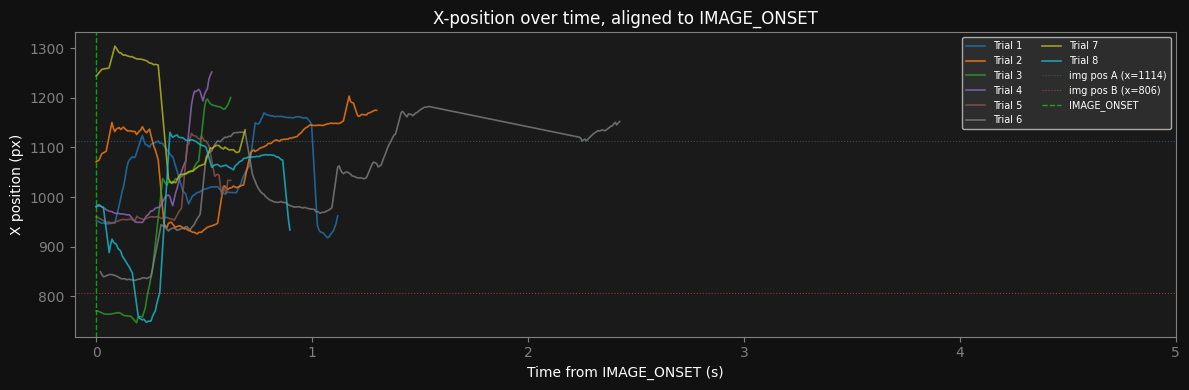

In [49]:
# --- Time vs x-position, trials aligned to IMAGE_ONSET (t=0) ---
fig, ax = plt.subplots(figsize=(12, 4))

colors = cm.tab10(np.linspace(0, 1, len(segments)))

for i, trial in enumerate(segments):
    seg = trial['seg']
    if len(seg) == 0:
        continue
    # t_rel is already computed relative to IMAGE_ONSET
    t_stop = stop_times[stop_times['TIME'] > seg['TIME'].iloc[0]]
    t_end  = t_stop.iloc[0]['TIME'] if len(t_stop) else seg['TIME'].iloc[-1]
    task   = seg[seg['TIME'] <= t_end]
    ax.plot(task['t_rel'], task['dx'] * SCREEN_W,
            color=colors[i], lw=1.2, alpha=0.8, label=f'Trial {i+1}')

# Image position reference lines (where images actually are on screen)
ax.axhline(1114, color='steelblue', ls=':', lw=0.8, alpha=0.5, label='img pos A (x=1114)')
ax.axhline(806,  color='tomato',    ls=':', lw=0.8, alpha=0.5, label='img pos B (x=806)')
ax.axvline(0, color='lime', lw=1.0, ls='--', alpha=0.6, label='IMAGE_ONSET')

ax.set_xlabel('Time from IMAGE_ONSET (s)')
ax.set_ylabel('X position (px)')
ax.set_xlim(-0.1, 5.0)
ax.set_facecolor('#1a1a1a')
ax.tick_params(colors='gray')
ax.yaxis.label.set_color('white')
ax.xaxis.label.set_color('white')
for spine in ax.spines.values():
    spine.set_edgecolor('gray')
ax.legend(facecolor='#333333', labelcolor='white', fontsize=7, ncol=2)

fig.patch.set_facecolor('#111111')
plt.title('X-position over time, aligned to IMAGE_ONSET', color='white')
plt.tight_layout()
plt.show()

In [50]:
# --- Balancing / randomization check ---
print("Image appearance count (each image should appear exactly twice):")
from collections import Counter
all_imgs = list(csv['img_left']) + list(csv['img_right'])
for img, n in sorted(Counter(all_imgs).items()):
    print(f"  {img}: {n}")

print("\nLeft/right position counterbalancing (x_left sign per trial):")
for _, r in csv.iterrows():
    side = 'img_left=RIGHT, img_right=LEFT' if r['x_left'] > 0 else 'img_left=LEFT,  img_right=RIGHT'
    print(f"  trial {r['trial_nr']}: {side}  (x_left={r['x_left']})")

print("\nImage pair assignments:")
for _, r in csv.iterrows():
    print(f"  trial {r['trial_nr']}: {r['img_left']} vs {r['img_right']}")

Image appearance count (each image should appear exactly twice):
  000.png: 2
  001.png: 1
  002.png: 2
  003.png: 2
  006.png: 2
  007.png: 2
  111.png: 1
  222.png: 2
  333.png: 2

Left/right position counterbalancing (x_left sign per trial):
  trial 1: img_left=RIGHT, img_right=LEFT  (x_left=154)
  trial 2: img_left=LEFT,  img_right=RIGHT  (x_left=-154)
  trial 3: img_left=RIGHT, img_right=LEFT  (x_left=154)
  trial 4: img_left=LEFT,  img_right=RIGHT  (x_left=-154)
  trial 5: img_left=RIGHT, img_right=LEFT  (x_left=154)
  trial 6: img_left=LEFT,  img_right=RIGHT  (x_left=-154)
  trial 7: img_left=RIGHT, img_right=LEFT  (x_left=154)
  trial 8: img_left=LEFT,  img_right=RIGHT  (x_left=-154)

Image pair assignments:
  trial 1: 000.png vs 111.png
  trial 2: 002.png vs 003.png
  trial 3: 222.png vs 333.png
  trial 4: 006.png vs 007.png
  trial 5: 001.png vs 000.png
  trial 6: 003.png vs 002.png
  trial 7: 333.png vs 222.png
  trial 8: 007.png vs 006.png
